In [ ]:
import tensorflow as tf

print("--- CEK STATUS HARDWARE ---")
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ GPU Terdeteksi: {len(gpu_devices)} unit")
    print("Detail GPU yang diberikan oleh Google:")
    # Memanggil command system Linux untuk melihat spek GPU NVIDIA
    !nvidia-smi
else:
    print("❌ GPU TIDAK TERDETEKSI. Pastikan Runtime sudah diubah ke T4 GPU.")

In [ ]:
# ===================================================================
# 0A. KAGGLE API & DATASET DOWNLOADER
# ===================================================================
import os
from google.colab import userdata

print("--- PHASE 1: CONFIGURING KAGGLE API TOKEN ---")
# Mengambil token rahasia dari brankas Google Colab (Secrets)
try:
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    print("✅ Kaggle API Token successfully loaded from Colab Secrets!")
except userdata.SecretNotFoundError:
    print("❌ ERROR: Secret 'KAGGLE_API_TOKEN' not found.")
    print("Please add it to the Secrets tab (key icon on the left sidebar).")
    raise

print("\n--- PHASE 2: DOWNLOADING CONCRETE CRACK DATASET ---")
# Download the dataset directly from Kaggle servers
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification

print("\n--- PHASE 3: DATA EXTRACTION (UNZIP) ---")
# Create the target directory
!mkdir -p /content/dataset_concrete
# Extract the zip file silently (-q) to the target directory
!unzip -q concrete-crack-images-for-classification.zip -d /content/dataset_concrete/

print("\n✅ Dataset successfully downloaded and extracted to: /content/dataset_concrete/")

In [ ]:
# ===================================================================
# 0B. HYPERPARAMETER DASHBOARD & REPRODUCIBILITY SETUP
# ===================================================================
import tensorflow as tf
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
import seaborn as sns
from google.colab import drive
import time

print("--- PHASE 1: CONNECT TO GOOGLE DRIVE ---")
# Mount Google Drive to save the trained models and CSV logs later
drive.mount('/content/drive')

print("\n--- PHASE 2: HYPERPARAMETER CONFIGURATION ---")
# -------------------------------------------------------------------
# EXPERIMENT DASHBOARD (Change these values for each scenario)
# -------------------------------------------------------------------
SCENARIO_NAME = "Scenario 4-Experiment_Smaller_Batch_Size_WeightLossTraining"

LEARNING_RATE = 0.001  # Options to test: 0.001, 0.0001, 0.01
BATCH_SIZE = 16        # Options to test: 16, 32, 64
EPOCHS = 20            # Fixed at 20 for fair comparison

# Path to the extracted dataset in Colab's temporary storage
DATA_DIR = "/content/dataset_concrete/"

# Define a specific folder in your Google Drive to keep things organized
SAVE_DIR = "/content/drive/MyDrive/Skripsi/Thesis_Experiments/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Create a safe filename by replacing spaces with underscores
safe_scenario_name = SCENARIO_NAME.replace(" ", "_").replace("-", "_")

# Master Seed to guarantee 100% reproducible results
MASTER_SEED = 42

# Class 0 = Intact, Class 1 = Cracked Weight LOss Penalty
weights = {0: 1.0, 1: 3.0}

# -------------------------------------------------------------------

print(f"\n[*] CURRENTLY RUNNING: {SCENARIO_NAME}")
print(f"[*] Parameters -> LR: {LEARNING_RATE} | Batch: {BATCH_SIZE} | Epochs: {EPOCHS}")

# Lock the environment with the Master Seed
random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)
tf.random.set_seed(MASTER_SEED)
os.environ['PYTHONHASHSEED'] = str(MASTER_SEED)
print("\n[+] Environment Locked. Ready for reproducible experiments!")

--- STEP 0: REPRODUCIBILITY SETUP ---
[*] Environment Locked. Master Seed: 42
--- STEP 1: DATA PREPROCESSING ---
Found 100 files belonging to 2 classes.
Using 70 files for training.
Found 100 files belonging to 2 classes.
Using 30 files for validation.

              DATASET SPLIT SUMMARY (3-WAY)             
Total Images Found    : 100 files
1. Training Set (70%) : 70 files (9 batches)
2. Remainder (30%)    : 30 files (4 batches)
--------------------------------------------------------
Splitting the 30% remainder evenly into Validation and Test:
-> Validation Set (15%) : 2 batches (~16 files)
-> Test Set (15%)       : 2 batches (~14 files)

--- STEP 2 & 3: MODEL ARCHITECTURE & TRAINING ---
Starting training for 5 epochs...
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.4143 - loss: 1.0498 - val_accuracy: 0.6875 - val_loss: 0.5273
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9429 - loss: 0.4255 - val_accuracy: 1.0000 - val_loss: 0.2339
Epoch 3/5
9/9 ━━━

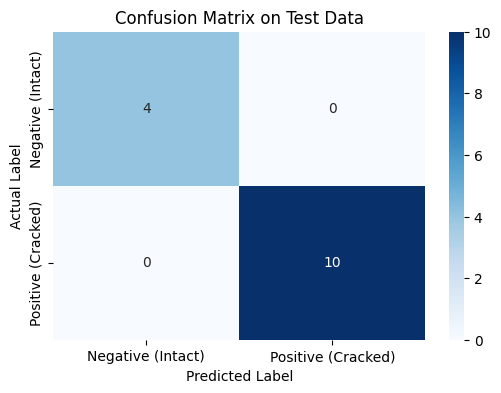

In [ ]:
# ===================================================================
# STEP 1: DATA PREPROCESSING
# ===================================================================
print("--- STEP 1: DATA PREPROCESSING ---")
IMG_SIZE = (224, 224)

# 1.a. Split Data into Training (70%) and Remainder (30%)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="training", seed=MASTER_SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

remainder_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.3, subset="validation", seed=MASTER_SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

# 1.b. Split Remainder into Validation (15%) and Test (15%)
remainder_batches = tf.data.experimental.cardinality(remainder_dataset)
midpoint = remainder_batches // 2

val_dataset = remainder_dataset.take(midpoint)
test_dataset = remainder_dataset.skip(midpoint)

# Extracting exact file counts from the dataset properties
total_files = len(train_dataset.file_paths) + len(remainder_dataset.file_paths)
train_files = len(train_dataset.file_paths)
remainder_files = len(remainder_dataset.file_paths)

val_batches = tf.data.experimental.cardinality(val_dataset).numpy()
test_batches = tf.data.experimental.cardinality(test_dataset).numpy()

# Calculating approximate images based on batches
# (Last batch might have fewer images, which is normal)
val_approx_files = val_batches * BATCH_SIZE
test_approx_files = remainder_files - val_approx_files

print("\n========================================================")
print("              DATASET SPLIT SUMMARY (3-WAY)             ")
print("========================================================")
print(f"Total Images Found    : {total_files} files")
print(f"1. Training Set (70%) : {train_files} files ({tf.data.experimental.cardinality(train_dataset).numpy()} batches)")
print(f"2. Remainder (30%)    : {remainder_files} files ({remainder_batches} batches)")
print("--------------------------------------------------------")
print("Splitting the 30% remainder evenly into Validation and Test:")
print(f"-> Validation Set (15%) : {val_batches} batches (~{val_approx_files} files)")
print(f"-> Test Set (15%)       : {test_batches} batches (~{test_approx_files} files)")

# 1.c. Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.shuffle(buffer_size=100, seed=MASTER_SEED).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# ===================================================================
# STEP 2 : BUILDING MODEL ARCHITECTURE
# ===================================================================
print("\n--- STEP 2 : BUILDING MODEL ARCHITECTURE ---")

# Data Augmentation (Prevents Overfitting by slightly modifying images during training)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])


# Load Pre-trained MobileNetV2 (This acts as our Automatic Feature Extractor)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model

# Build the complete model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None, None, 3)),    # 1. EXPLICIT INPUT LAYER
    tf.keras.layers.Resizing(224, 224),              # 2. Resize images
    data_augmentation,                               # 3. Augment the image (Rotate/Flip)
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # 4. Normalize pixels (-1 to 1)
    base_model,                                      # 5. Extract Features (MobileNetV2)
    tf.keras.layers.GlobalAveragePooling2D(),        # 6. Pooling (Flatten to 1D)
    tf.keras.layers.Dense(1, activation='sigmoid')   # 7. Output Prediction
])


# Compile the model (Configuring the learning process)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- ARCHITECTURE SUMMARY ---")
model.summary()



# ===================================================================
# STEP 3: AUTOMATIC FEATURE EXTRACTION & MODEL TRAINING
# ===================================================================
print("\n--- STEP 3: AUTOMATIC FEATURE EXTRACTION & MODEL TRAINING ---")

checkpoint_path = os.path.join(SAVE_DIR, f"{safe_scenario_name}_Best_Model.keras")

checkpoint_monitor = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',       
    save_best_only=True,      
    mode='min',               
    verbose=1                 
)

start_time = time.time()

# Train the model
print(f"Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=weights,
    callbacks=[checkpoint_monitor]
)

end_time = time.time()

total_time_seconds = end_time - start_time
minutes = int(total_time_seconds // 60)
seconds = int(total_time_seconds % 60)

print(f"\n⏱️ TOTAL TRAINING TIME: {minutes} minutes {seconds} seconds")

# ===================================================================
# STEP 4: EXPORTING METRICS FOR THESIS ANALYSIS
# ===================================================================

# EXPORT TRAINING HISTORY TO CSV (GOOGLE DRIVE)

print("\n--- STEP 4: EXPORTING METRICS FOR THESIS ANALYSIS ---")

# Convert the training history dictionary into a Pandas DataFrame
history_df = pd.DataFrame(history.history)

# Add an 'Epoch' column starting from 1 for easier Excel plotting
history_df.insert(0, 'Epoch', range(1, len(history_df) + 1))

best_epoch_idx = np.argmin(history_df['val_loss'])
best_epoch_num = best_epoch_idx + 1

history_df['Is_Best_Model'] = False
history_df.loc[best_epoch_idx, 'Is_Best_Model'] = True

print(f"[*] Best Model observed in Epoch {best_epoch_num}")
print(f"    - Val Loss     : {history_df.loc[best_epoch_idx, 'val_loss']:.6f}")
print(f"    - Val Accuracy : {history_df.loc[best_epoch_idx, 'val_accuracy']:.6f}")

print(history_df)

csv_filename = os.path.join(SAVE_DIR, f"{safe_scenario_name}_history.csv")

# Save the DataFrame to a CSV file
history_df.to_csv(csv_filename, index=False)

print(f"✅ SUCCESS: Training history saved to -> {csv_filename}")
print("You can now download this CSV file to create combined comparison charts in Excel!")

print("\n--- VISUALIZING TRAINING HISTORY ---")
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', color='orange')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss (Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Model Loss (Error) over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()

plot_filename = os.path.join(SAVE_DIR, f"{safe_scenario_name}_Learning_Curve.png")
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"✅ SUCCESS: HD Learning Curve saved to -> {plot_filename}")

plt.show()



# ===================================================================
# STEP 5: MODEL TESTING
# ===================================================================
print("\n--- STEP 5: MODEL TESTING ---")
print("Evaluating model performance on the unseen Test Dataset...")
print("Using best model...")
best_model = tf.keras.models.load_model(checkpoint_path)
loss, accuracy = best_model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")



# ===================================================================
# STEP 6: MODEL EVALUATION (METRICS)
# ===================================================================
print("\n--- STEP 6: MODEL EVALUATION ---")

true_labels = []
predictions = []

# Extract true labels and predictions from the Test Set
for images, labels in test_dataset:
    true_labels.extend(labels.numpy())
    batch_preds = best_model.predict(images, verbose=0)
    predictions.extend(batch_preds)

true_labels = np.array(true_labels)
predicted_classes = (np.array(predictions) > 0.5).astype(int).flatten()
target_names = ['Negative (Intact)', 'Positive (Cracked)']

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_classes, target_names=target_names, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(true_labels, predicted_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix on Test Data')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

cm_filename = os.path.join(SAVE_DIR, f"{safe_scenario_name}_Confusion_Matrix.png")
plt.savefig(cm_filename, dpi=300, bbox_inches='tight')
print(f"✅ SUCCESS: HD Confusion Matrix saved to -> {cm_filename}")

plt.show()

In [ ]:
model.save(f'/content/drive/MyDrive/Skripsi/model_{safe_scenario_name}.h5')
print("Model success exported to Google Drive!")